# Exercise 1. 피싱 웹사이트 분류 — 완전 실습
**목표:** 데이터 점검 → 전처리 → 6개 분류 모델 비교 → 혼동행렬·ROC/PR 곡선 → 교차검증 → 특성 중요도 → 결과 저장

정답은 `label`이며 `normal=0`, `phishing=1`로 사용합니다. 보안 탐지에서는 피싱을 정상으로 놓치는 **FN(미탐)**과 정상 사이트를 피싱으로 판단하는 **FP(오탐)**을 구분해야 합니다.

In [ ]:
import warnings, os, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from IPython.display import display
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns",100)
print("환경 준비 완료")

환경 준비 완료


In [ ]:
EXPECTED_KEYWORD="phishing_websites"
paths=(glob.glob("/content/*.csv")+glob.glob("/content/drive/MyDrive/**/*.csv",recursive=True)
       +glob.glob("./*.csv")+glob.glob("/mnt/data/*.csv"))
matched=[p for p in paths if EXPECTED_KEYWORD.lower() in os.path.basename(p).lower()]
if not matched:
    from google.colab import files
    print("CSV 파일을 업로드하세요.")
    uploaded=files.upload()
    matched=list(uploaded.keys())
file_path=matched[0]
df=pd.read_csv(file_path)
print("파일:",file_path,"크기:",df.shape)
display(df.head())

CSV 파일을 업로드하세요.


Saving Exercise1. phishing_websites_sample.csv to Exercise1. phishing_websites_sample.csv
파일: Exercise1. phishing_websites_sample.csv 크기: (1000, 31)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,label
0,-1,-1,-1,1,-1,-1,-1,-1,1,1,1,1,-1,0,-1,-1,1,1,0,1,-1,1,1,-1,1,-1,1,1,0,-1,phishing
1,1,-1,1,1,1,-1,1,-1,1,1,1,1,-1,-1,0,-1,1,1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,phishing
2,1,-1,1,1,1,-1,0,0,1,1,1,1,-1,0,-1,-1,1,1,0,1,1,1,1,1,-1,-1,-1,1,1,1,phishing
3,1,-1,1,1,1,-1,-1,1,-1,1,1,1,1,0,0,-1,1,1,0,1,1,1,1,1,-1,0,-1,-1,1,1,phishing
4,1,-1,1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,1,1,1,1,-1,1,1,-1,1,0,1,normal


## 1. 데이터 품질 확인
결측치, 중복값, 자료형, 클래스 불균형을 확인합니다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   having_IP_Address            1000 non-null   int64 
 1   URL_Length                   1000 non-null   int64 
 2   Shortining_Service           1000 non-null   int64 
 3   having_At_Symbol             1000 non-null   int64 
 4   double_slash_redirecting     1000 non-null   int64 
 5   Prefix_Suffix                1000 non-null   int64 
 6   having_Sub_Domain            1000 non-null   int64 
 7   SSLfinal_State               1000 non-null   int64 
 8   Domain_registeration_length  1000 non-null   int64 
 9   Favicon                      1000 non-null   int64 
 10  port                         1000 non-null   int64 
 11  HTTPS_token                  1000 non-null   int64 
 12  Request_URL                  1000 non-null   int64 
 13  URL_of_Anchor                1000 

,결측치
having_IP_Address,0
URL_Length,0
Shortining_Service,0
having_At_Symbol,0
double_slash_redirecting,0
Prefix_Suffix,0
having_Sub_Domain,0
SSLfinal_State,0
Domain_registeration_length,0
Favicon,0


,개수
label,
phishing,500
normal,500


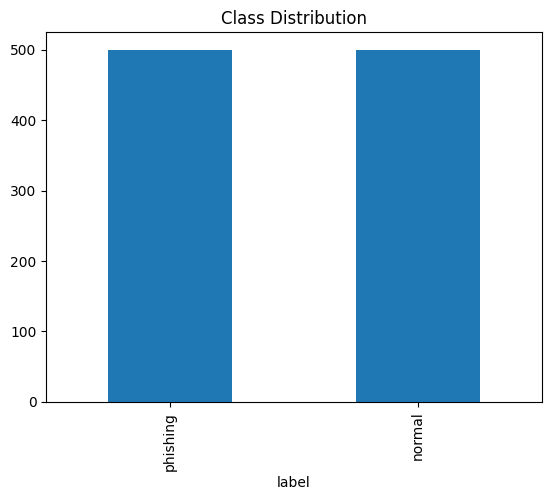

In [ ]:
# ============================================================
# 2번째 코드 셀: 피싱 웹사이트 분류 실습 코드 상세 설명
# ============================================================

# 행 수, 컬럼 이름, 자료형, 결측값 여부 등 데이터 구조를 확인합니다.
print(df.info())

# 완전히 동일하게 반복된 중복 행의 개수를 계산합니다.
print("중복:",df.duplicated().sum())

# 컬럼별 결측값 개수를 계산합니다.
display(df.isnull().sum().sort_values(ascending=False).head(10).to_frame("결측치"))

# 각 범주가 데이터에 몇 번 등장하는지 개수를 계산합니다.
display(df["label"].value_counts().to_frame("개수"))

# 각 범주가 데이터에 몇 번 등장하는지 개수를 계산합니다.
(df["label"].value_counts()).plot(kind="bar",title="Class Distribution"); plt.show()

## 2. 전처리 및 데이터 분할
중복 제거, 결측치 최빈값 대치, 8:2 층화 분할을 수행합니다. 표준화는 Pipeline 안에서 학습 데이터에만 적용하여 데이터 누수를 방지합니다.

In [ ]:
# ============================================================
# 3번째 코드 셀: 피싱 웹사이트 분류 실습 코드 상세 설명
# ============================================================

# 데이터를 모델 학습용과 최종 평가용으로 나눕니다.
from sklearn.model_selection import train_test_split

# 전처리와 모델 학습 단계를 정해진 순서로 묶어 한 번에 실행합니다.
from sklearn.pipeline import Pipeline

# 비어 있는 결측값을 지정한 대표값으로 채우는 전처리 도구입니다.
from sklearn.impute import SimpleImputer

# 변수마다 단위가 다른 문제를 줄이기 위해 값을 표준화합니다.
from sklearn.preprocessing import StandardScaler

# 완전히 동일한 중복 행을 제거하고 행 번호를 다시 정리합니다.
data=df.drop_duplicates().reset_index(drop=True)

# 모델 학습에 사용하지 않을 식별자 또는 정답 컬럼을 제거합니다.
X=data.drop(columns="label")

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
y=data["label"].map({"normal":0,"phishing":1})

# 조건이 참일 때만 아래 코드를 실행하도록 검사합니다.
if y.isnull().any(): raise ValueError("label 값 확인 필요")

# 데이터를 모델 학습용과 최종 평가용으로 나눕니다.
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,stratify=y,random_state=RANDOM_STATE)

# 현재 처리 결과를 사용자가 확인할 수 있도록 화면에 출력합니다.
print(X_train.shape,X_test.shape)

(736, 30) (185, 30)


## 3. 모델 학습
로지스틱 회귀, KNN, 나이브베이즈, SVM, 의사결정나무, 랜덤포레스트를 같은 데이터로 비교합니다.

In [ ]:
# ============================================================
# 4번째 코드 셀: 피싱 웹사이트 분류 실습 코드 상세 설명
# ============================================================

# 정상과 피싱 같은 두 클래스를 확률적으로 분류하는 로지스틱 회귀입니다.
from sklearn.linear_model import LogisticRegression

# 주변의 가까운 데이터가 어떤 클래스인지 참고하는 KNN 분류 모델입니다.
from sklearn.neighbors import KNeighborsClassifier

# 각 특성이 독립적이라고 가정하는 확률 기반 나이브베이즈 모델입니다.
from sklearn.naive_bayes import GaussianNB

# 클래스 사이의 간격을 최대화하는 SVM 분류 모델입니다.
from sklearn.svm import SVC

# 조건을 순차적으로 나누어 정답을 예측하는 의사결정나무입니다.
from sklearn.tree import DecisionTreeClassifier

# 여러 의사결정나무의 결과를 결합하는 랜덤포레스트 분류 모델입니다.
from sklearn.ensemble import RandomForestClassifier

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
models={

 # 비어 있는 결측값을 지정한 대표값으로 채우는 전처리 도구입니다.
"Logistic":Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("sc",StandardScaler()),("m",LogisticRegression(max_iter=2000))]),

 # 비어 있는 결측값을 지정한 대표값으로 채우는 전처리 도구입니다.
"KNN":Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("sc",StandardScaler()),("m",KNeighborsClassifier())]),

 # 비어 있는 결측값을 지정한 대표값으로 채우는 전처리 도구입니다.
"Naive Bayes":Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("sc",StandardScaler()),("m",GaussianNB())]),

 # 비어 있는 결측값을 지정한 대표값으로 채우는 전처리 도구입니다.
"SVM":Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("sc",StandardScaler()),("m",SVC(probability=True,random_state=RANDOM_STATE))]),

 # 비어 있는 결측값을 지정한 대표값으로 채우는 전처리 도구입니다.
"Decision Tree":Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("m",DecisionTreeClassifier(max_depth=6,random_state=RANDOM_STATE))]),

 # 비어 있는 결측값을 지정한 대표값으로 채우는 전처리 도구입니다.
"Random Forest":Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("m",RandomForestClassifier(n_estimators=200,class_weight="balanced",n_jobs=-1,random_state=RANDOM_STATE))])
}

## 4. 평가지표
Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC를 계산합니다. 미탐 방지가 중요하면 Recall, 오탐 억제가 중요하면 Precision을 중점적으로 봅니다.

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
5,Random Forest,0.9351,0.9556,0.9149,0.9348,0.9853,0.9865
4,Decision Tree,0.9081,0.8889,0.9362,0.9119,0.9611,0.9592
3,SVM,0.9135,0.9535,0.8723,0.9111,0.9749,0.9773
0,Logistic,0.9081,0.9140,0.9043,0.9091,0.9753,0.9780
1,KNN,0.9027,0.9222,0.8830,0.9022,0.9501,0.9375
2,Naive Bayes,0.6162,0.5697,1.0000,0.7259,0.9769,0.9776


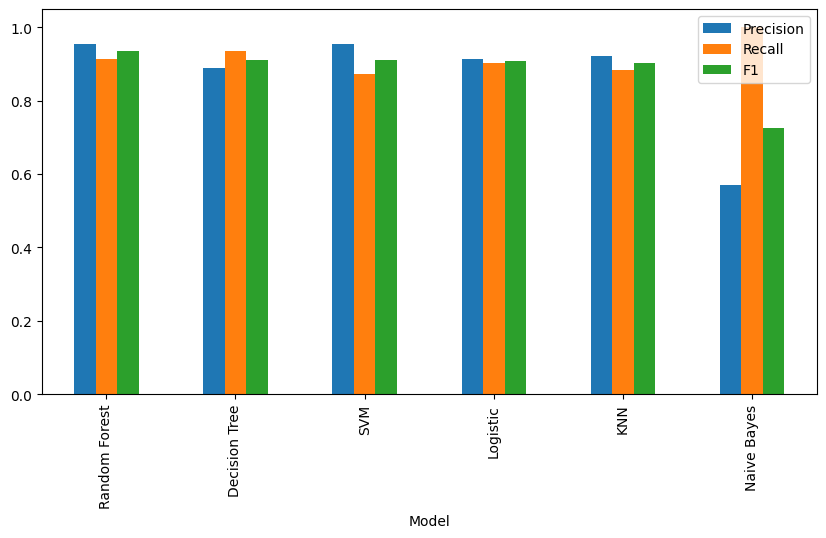

In [ ]:
# ============================================================
# 5번째 코드 셀: 피싱 웹사이트 분류 실습 코드 상세 설명
# ============================================================

# 아래 명령을 실행하여 현재 단계의 데이터 처리 또는 분석을 수행합니다.
from sklearn.metrics import *

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
rows=[]; preds={}; scores={}

# 여러 모델이나 여러 설정값을 하나씩 반복해서 처리하기 위한 반복문입니다.
for name,m in models.items():
    # 주어진 학습 데이터의 패턴을 모델이 학습하도록 합니다.
    m.fit(X_train,y_train); p=m.predict(X_test); s=m.predict_proba(X_test)[:,1]
    # 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
    preds[name]=p; scores[name]=s
    # 전체 예측 중 맞힌 비율인 정확도를 계산합니다.
    rows.append([name,accuracy_score(y_test,p),precision_score(y_test,p),recall_score(y_test,p),
                 # 공격이라고 예측한 것 중 실제 공격인 비율인 정밀도를 계산합니다.
                 f1_score(y_test,p),roc_auc_score(y_test,s),average_precision_score(y_test,s)])

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
result=pd.DataFrame(rows,columns=["Model","Accuracy","Precision","Recall","F1","ROC_AUC","PR_AUC"]).sort_values("F1",ascending=False)

# 계산된 표를 보기 좋은 데이터프레임 형태로 화면에 출력합니다.
display(result.round(4))

# 완성된 그래프를 화면에 출력합니다.
result.set_index("Model")[["Precision","Recall","F1"]].plot(kind="bar",figsize=(10,5)); plt.ylim(0,1.05); plt.show()

## 5. 혼동행렬·분류 보고서

최우수: Random Forest
              precision    recall  f1-score   support

      normal     0.9158    0.9560    0.9355        91
    phishing     0.9556    0.9149    0.9348        94

    accuracy                         0.9351       185
   macro avg     0.9357    0.9355    0.9351       185
weighted avg     0.9360    0.9351    0.9351       185



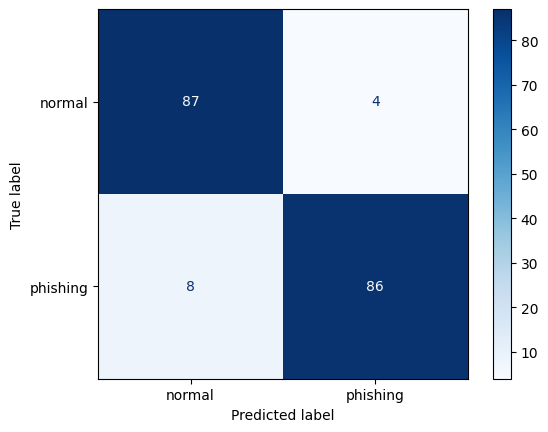

In [ ]:
# ============================================================
# 6번째 코드 셀: 피싱 웹사이트 분류 실습 코드 상세 설명
# ============================================================

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
best=result.iloc[0]["Model"]; bp=preds[best]

# 클래스별 Precision, Recall, F1-score를 한 번에 출력합니다.
print("최우수:",best); print(classification_report(y_test,bp,target_names=["normal","phishing"],digits=4))

# 정상·공격 예측 결과를 혼동행렬로 시각화합니다.
ConfusionMatrixDisplay.from_predictions(y_test,bp,display_labels=["normal","phishing"],cmap="Blues"); plt.show()

## 6. ROC 및 Precision-Recall 곡선

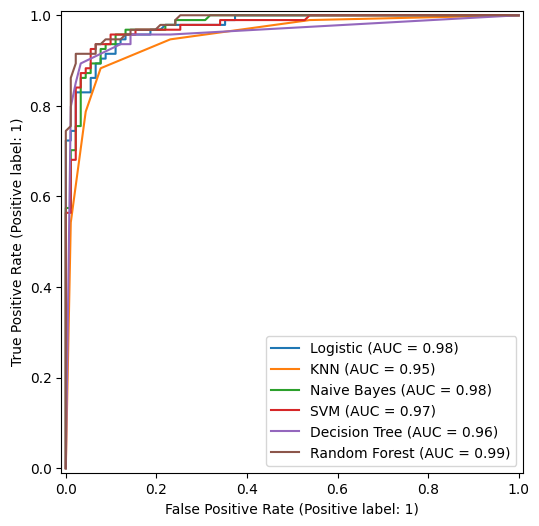

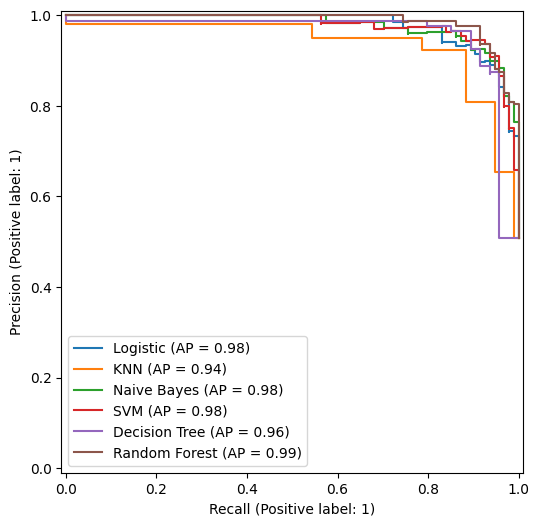

In [ ]:
# ============================================================
# 7번째 코드 셀: 피싱 웹사이트 분류 실습 코드 상세 설명
# ============================================================

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
fig,ax=plt.subplots(figsize=(7,6))

# 여러 모델이나 여러 설정값을 하나씩 반복해서 처리하기 위한 반복문입니다.
for n,s in scores.items(): RocCurveDisplay.from_predictions(y_test,s,name=n,ax=ax)

# 완성된 그래프를 화면에 출력합니다.
plt.show()

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
fig,ax=plt.subplots(figsize=(7,6))

# 여러 모델이나 여러 설정값을 하나씩 반복해서 처리하기 위한 반복문입니다.
for n,s in scores.items(): PrecisionRecallDisplay.from_predictions(y_test,s,name=n,ax=ax)

# 완성된 그래프를 화면에 출력합니다.
plt.show()

## 7. 임계값 조정
임계값을 낮추면 일반적으로 Recall은 높아지고 오탐이 증가할 수 있습니다.

In [ ]:
# ============================================================
# 8번째 코드 셀: 피싱 웹사이트 분류 실습 코드 상세 설명
# ============================================================

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
s=scores["Random Forest"]; rows=[]

# 여러 모델이나 여러 설정값을 하나씩 반복해서 처리하기 위한 반복문입니다.
for t in [.3,.4,.5,.6,.7]:
    # 공격이라고 예측한 것 중 실제 공격인 비율인 정밀도를 계산합니다.
    p=(s>=t).astype(int); rows.append([t,precision_score(y_test,p),recall_score(y_test,p),f1_score(y_test,p)])

# 계산된 표를 보기 좋은 데이터프레임 형태로 화면에 출력합니다.
display(pd.DataFrame(rows,columns=["Threshold","Precision","Recall","F1"]).round(4))

,Threshold,Precision,Recall,F1
0,0.3,0.8900,0.9468,0.9175
1,0.4,0.9263,0.9362,0.9312
2,0.5,0.9348,0.9149,0.9247
3,0.6,0.9767,0.8936,0.9333
4,0.7,0.9875,0.8404,0.9080


## 9. 랜덤포레스트 특성 중요도
중요도는 모델이 분할에 많이 활용한 정도이며 인과관계를 의미하지 않습니다.

,Feature,Importance
7,SSLfinal_State,0.351012
13,URL_of_Anchor,0.208164
25,web_traffic,0.074692
6,having_Sub_Domain,0.071814
14,Links_in_tags,0.046594
5,Prefix_Suffix,0.035093
15,SFH,0.023267
28,Links_pointing_to_page,0.017871
23,age_of_domain,0.017792
12,Request_URL,0.015455


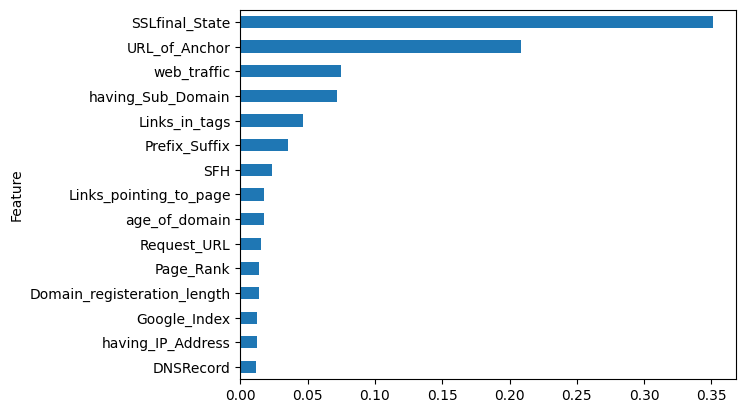

In [ ]:
# ============================================================
# 9번째 코드 셀: 피싱 웹사이트 분류 실습 코드 상세 설명
# ============================================================

# 주어진 학습 데이터의 패턴을 모델이 학습하도록 합니다.
rf=models["Random Forest"].fit(X_train,y_train).named_steps["m"]

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
imp=pd.DataFrame({"Feature":X.columns,"Importance":rf.feature_importances_}).sort_values("Importance",ascending=False).head(15)

# 완성된 그래프를 화면에 출력합니다.
display(imp); imp.sort_values("Importance").plot(x="Feature",y="Importance",kind="barh",legend=False); plt.show()

In [ ]:
# ============================================================
# 10번째 코드 셀: 피싱 웹사이트 분류 실습 코드 상세 설명
# ============================================================

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
output_path="/content/exercise1_results.csv" if os.path.isdir("/content") else "./exercise1_results.csv"

# 최종 결과를 나중에 다시 확인할 수 있도록 CSV 파일로 저장합니다.
result.to_csv(output_path,index=False,encoding="utf-8-sig"); print("저장 완료")

저장 완료
